# Recommender Sweep Analysis

This notebook loads recommender sweep outputs from `sweep_results/recommender`, finds the best configuration, and plots how each hyperparameter affects the selected metric.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("ggplot")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)


In [9]:
SWEEP_ROOT = Path("../sweep_results/recommender")
RUN_ID_FILTER = None
SWEEP_BATCH_FILTER = None
SWEEP_KIND_FILTER = None
ANALYSIS_SWEEP_KIND = "clustering"  # Optional override: "recommender" or "clustering"
PRIMARY_METRIC = "spearman_at_8"
TOP_N = 10

print(f"Sweep root: {SWEEP_ROOT.resolve()}")
print(f"Run filter: {RUN_ID_FILTER}")
print(f"Batch filter: {SWEEP_BATCH_FILTER}")
print(f"Sweep kind filter: {SWEEP_KIND_FILTER}")
print(f"Analysis sweep kind override: {ANALYSIS_SWEEP_KIND}")
print(f"Primary metric: {PRIMARY_METRIC}")


Sweep root: /gpfs/helios/home/kelemnegasi/fed-xai/fed-perso-xai/sweep_results/recommender
Run filter: None
Batch filter: None
Sweep kind filter: None
Analysis sweep kind override: clustering
Primary metric: spearman_at_8


In [10]:
def load_sweep_trials(sweep_root: Path, run_id_filter=None, batch_filter=None, sweep_kind_filter=None) -> pd.DataFrame:
    records = []
    for config_path in sorted(sweep_root.glob("**/config.json")):
        trial_dir = config_path.parent
        metrics_path = trial_dir / "metrics_summary.json"
        if not metrics_path.exists():
            continue

        with config_path.open("r", encoding="utf-8") as f:
            config = json.load(f)
        with metrics_path.open("r", encoding="utf-8") as f:
            metrics = json.load(f)

        run_id = config["run_id"]
        batch_id = config["sweep_batch_id"]
        sweep_kind = config.get("sweep_kind", "recommender")
        if run_id_filter and run_id != run_id_filter:
            continue
        if batch_filter and batch_id != batch_filter:
            continue
        if sweep_kind_filter and sweep_kind != sweep_kind_filter:
            continue

        hyper = config.get("hyperparameters", {})
        clustering = config.get("clustering", {})
        aggregate = metrics.get("aggregate", {})
        client_metrics = metrics.get("clients", {})
        client_spearman = {
            client_id: values.get("spearman")
            for client_id, values in client_metrics.items()
        }

        record = {
            "run_id": run_id,
            "sweep_batch_id": batch_id,
            "trial_id": config.get("trial_id"),
            "mode": config.get("mode"),
            "sweep_kind": sweep_kind,
            "selection_id": config.get("selection_id"),
            "persona_assignment_policy": config.get("persona_assignment_policy"),
            "fixed_persona": config.get("fixed_persona"),
            "persona_assignment_alpha": config.get("persona_assignment_alpha"),
            "label_namespace": config.get("label_namespace"),
            "train_rounds": hyper.get("train_rounds"),
            "train_epochs": hyper.get("train_epochs"),
            "train_batch_size": hyper.get("train_batch_size"),
            "train_learning_rate": hyper.get("train_learning_rate"),
            "train_svm_c": hyper.get("train_svm_c"),
            "train_svm_intercept_scaling": hyper.get("train_svm_intercept_scaling"),
            "clustering_k": clustering.get("clustering_k"),
            "clustering_warmup_rounds": clustering.get("clustering_warmup_rounds"),
            "clustering_freeze_pca_after_warmup": clustering.get("clustering_freeze_pca_after_warmup"),
            "clustering_enable_pca": clustering.get("clustering_enable_pca"),
            "clustering_representation": clustering.get("clustering_representation"),
            "clustering_assignment_margin": clustering.get("clustering_assignment_margin"),
            "clustering_num_restarts": clustering.get("clustering_num_restarts"),
            "spearman_at_3": aggregate.get("spearman_at_3"),
            "spearman_at_5": aggregate.get("spearman_at_5"),
            "spearman_at_8": aggregate.get("spearman_at_8"),
            "mean_client_spearman": (
                float(np.mean(list(client_spearman.values()))) if client_spearman else np.nan
            ),
            "std_client_spearman": (
                float(np.std(list(client_spearman.values()))) if client_spearman else np.nan
            ),
            "client_spearman": client_spearman,
            "trial_dir": config.get("paths", {}).get("trial_dir"),
            "evaluation_summary_path": config.get("paths", {}).get("evaluation_summary"),
            "metrics_summary_path": config.get("paths", {}).get("metrics_summary"),
        }
        records.append(record)

    if not records:
        return pd.DataFrame()

    df = pd.DataFrame.from_records(records)
    df = df.sort_values(
        by=[PRIMARY_METRIC, "spearman_at_5", "spearman_at_3"],
        ascending=False,
    ).reset_index(drop=True)
    return df


df = load_sweep_trials(SWEEP_ROOT, RUN_ID_FILTER, SWEEP_BATCH_FILTER, SWEEP_KIND_FILTER)
print(f"Loaded {len(df)} completed trials")
df.head(3)


Loaded 288 completed trials


,run_id,sweep_batch_id,trial_id,mode,sweep_kind,selection_id,persona_assignment_policy,fixed_persona,persona_assignment_alpha,label_namespace,train_rounds,train_epochs,train_batch_size,train_learning_rate,train_svm_c,train_svm_intercept_scaling,clustering_k,clustering_warmup_rounds,clustering_freeze_pca_after_warmup,clustering_enable_pca,clustering_representation,clustering_assignment_margin,clustering_num_restarts,spearman_at_3,spearman_at_5,spearman_at_8,mean_client_spearman,std_client_spearman,client_spearman,trial_dir,evaluation_summary_path,metrics_summary_path
0,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t214035-251961,lr-0p005__c-15p0__rounds-150__epochs-3,plain,recommender,test__max-40__seed-42,fixed,lay,None,lay__20260512t214035-251961__lr-0p005__c-15p0__rounds-150__epochs-3,150,3,2048,0.005,15.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.598539,0.751515,0.900956,0.791639,0.092782,"{'client_000': 0.75936639004036, 'client_001': 0.6357455862610503, 'client_002': 0.7618087184851952, 'client_003': 0...",sweep_results/recommender/federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed...,sweep_results/recommender/federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed...,sweep_results/recommender/federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed...
1,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t214035-251961,lr-0p01__c-7p5__rounds-150__epochs-3,plain,recommender,test__max-40__seed-42,fixed,lay,None,lay__20260512t214035-251961__lr-0p01__c-7p5__rounds-150__epochs-3,150,3,2048,0.010,7.5,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.598539,0.751515,0.900956,0.791639,0.092782,"{'client_000': 0.75936639004036, 'client_001': 0.6357455862610503, 'client_002': 0.7618087184851952, 'client_003': 0...",sweep_results/recommender/federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed...,sweep_results/recommender/federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed...,sweep_results/recommender/federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed...
2,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t222046-276834,k-2__warmup-30__freeze-0__pca-0__repr-delta__margin-0p02__restarts-5,clustered,clustering,test__max-40__seed-42,fixed,lay,None,lay__20260512t222046-276834__k-2__warmup-30__freeze-0__pca-0__repr-delta__margin-0p02__restarts-5,150,3,2048,0.005,15.0,1.0,2.0,30.0,0.0,0.0,delta,0.02,5.0,0.598539,0.751421,0.900956,0.791898,0.092356,"{'client_000': 0.7603006784240411, 'client_001': 0.6371809550160066, 'client_002': 0.7607174136501356, 'client_003':...",sweep_results/recommender/federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed...,sweep_results/recommender/federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed...,sweep_results/recommender/federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed...


In [11]:
if df.empty:
    raise RuntimeError("No completed sweep trials were found for the current filters.")

available_sweep_kinds = sorted(df["sweep_kind"].dropna().unique())
requested_sweep_kind = ANALYSIS_SWEEP_KIND or SWEEP_KIND_FILTER
if requested_sweep_kind is not None and requested_sweep_kind not in available_sweep_kinds:
    raise RuntimeError(
        f"Requested sweep kind {requested_sweep_kind!r} is not available. Found: {available_sweep_kinds}"
    )

if requested_sweep_kind is None:
    if len(available_sweep_kinds) == 1:
        requested_sweep_kind = available_sweep_kinds[0]
    elif "recommender" in available_sweep_kinds:
        requested_sweep_kind = "recommender"
    else:
        requested_sweep_kind = available_sweep_kinds[0]

sweep_kind = requested_sweep_kind
df = df[df["sweep_kind"] == sweep_kind].reset_index(drop=True)
print(f"Analyzing sweep kind: {sweep_kind} ({len(df)} trials)")
if sweep_kind == "clustering":
    summary_columns = [
        "run_id",
        "sweep_batch_id",
        "trial_id",
        "mode",
        "sweep_kind",
        "fixed_persona",
        "train_learning_rate",
        "train_svm_c",
        "train_rounds",
        "train_epochs",
        "clustering_k",
        "clustering_warmup_rounds",
        "clustering_freeze_pca_after_warmup",
        "clustering_enable_pca",
        "clustering_representation",
        "clustering_assignment_margin",
        "clustering_num_restarts",
        "spearman_at_3",
        "spearman_at_5",
        "spearman_at_8",
        "mean_client_spearman",
    ]
else:
    summary_columns = [
        "run_id",
        "sweep_batch_id",
        "trial_id",
        "mode",
        "sweep_kind",
        "fixed_persona",
        "train_learning_rate",
        "train_svm_c",
        "train_rounds",
        "train_epochs",
        "spearman_at_3",
        "spearman_at_5",
        "spearman_at_8",
        "mean_client_spearman",
    ]

best_row = df.iloc[0]
display(df[summary_columns].head(TOP_N))

print("Best configuration")
display(best_row[summary_columns])


Analyzing sweep kind: clustering (144 trials)


,run_id,sweep_batch_id,trial_id,mode,sweep_kind,fixed_persona,train_learning_rate,train_svm_c,train_rounds,train_epochs,clustering_k,clustering_warmup_rounds,clustering_freeze_pca_after_warmup,clustering_enable_pca,clustering_representation,clustering_assignment_margin,clustering_num_restarts,spearman_at_3,spearman_at_5,spearman_at_8,mean_client_spearman
0,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t222046-276834,k-2__warmup-30__freeze-0__pca-0__repr-delta__margin-0p02__restarts-5,clustered,clustering,lay,0.005,15.0,150,3,2.0,30.0,0.0,0.0,delta,0.02,5.0,0.598539,0.751421,0.900956,0.791898
1,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t222046-276834,k-2__warmup-15__freeze-0__pca-0__repr-model__margin-0p1__restarts-10,clustered,clustering,lay,0.005,15.0,150,3,2.0,15.0,0.0,0.0,model,0.10,10.0,0.598539,0.751421,0.900892,0.791598
2,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t222046-276834,k-2__warmup-5__freeze-0__pca-0__repr-delta__margin-0p0__restarts-10,clustered,clustering,lay,0.005,15.0,150,3,2.0,5.0,0.0,0.0,delta,0.00,10.0,0.594931,0.747690,0.900824,0.791930
3,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t222046-276834,k-4__warmup-30__freeze-0__pca-0__repr-delta__margin-0p02__restarts-5,clustered,clustering,lay,0.005,15.0,150,3,4.0,30.0,0.0,0.0,delta,0.02,5.0,0.600168,0.753705,0.900175,0.791931
4,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t222046-276834,k-4__warmup-30__freeze-0__pca-0__repr-delta__margin-0p05__restarts-5,clustered,clustering,lay,0.005,15.0,150,3,4.0,30.0,0.0,0.0,delta,0.05,5.0,0.600168,0.753705,0.900175,0.791931
5,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t222046-276834,k-4__warmup-30__freeze-0__pca-0__repr-delta__margin-0p0__restarts-5,clustered,clustering,lay,0.005,15.0,150,3,4.0,30.0,0.0,0.0,delta,0.00,5.0,0.600168,0.753705,0.900175,0.791931
6,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t222046-276834,k-4__warmup-30__freeze-0__pca-0__repr-delta__margin-0p1__restarts-5,clustered,clustering,lay,0.005,15.0,150,3,4.0,30.0,0.0,0.0,delta,0.10,5.0,0.600168,0.753705,0.900175,0.791931
7,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t222046-276834,k-2__warmup-5__freeze-0__pca-0__repr-model__margin-0p05__restarts-10,clustered,clustering,lay,0.005,15.0,150,3,2.0,5.0,0.0,0.0,model,0.05,10.0,0.598358,0.751409,0.900097,0.791430
8,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t222046-276834,k-2__warmup-15__freeze-0__pca-0__repr-delta__margin-0p05__restarts-10,clustered,clustering,lay,0.005,15.0,150,3,2.0,15.0,0.0,0.0,delta,0.05,10.0,0.598530,0.751291,0.900076,0.792121
9,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t222046-276834,k-2__warmup-5__freeze-0__pca-0__repr-delta__margin-0p05__restarts-5,clustered,clustering,lay,0.005,15.0,150,3,2.0,5.0,0.0,0.0,delta,0.05,5.0,0.598530,0.749727,0.900059,0.791721


Best configuration


run_id                                federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03
sweep_batch_id                                                                                                           20260512t222046-276834
trial_id                                                                   k-2__warmup-30__freeze-0__pca-0__repr-delta__margin-0p02__restarts-5
mode                                                                                                                                  clustered
sweep_kind                                                                                                                           clustering
fixed_persona                                                                                                                               lay
train_learning_rate                                                                                                                     

,client_id,spearman
0,client_012,0.928588
1,client_008,0.916975
2,client_011,0.869933
3,client_013,0.863641
4,client_009,0.848609
5,client_007,0.848470
6,client_004,0.831511
7,client_003,0.799620
8,client_005,0.791825
9,client_002,0.761809


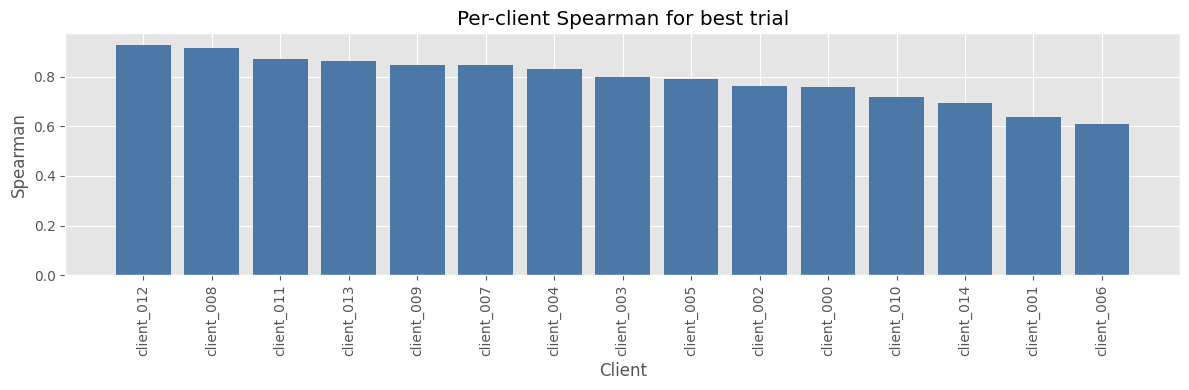

In [5]:
best_client_df = (
    pd.Series(best_row["client_spearman"], name="spearman")
    .sort_values(ascending=False)
    .rename_axis("client_id")
    .reset_index()
)
display(best_client_df)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(best_client_df["client_id"], best_client_df["spearman"], color="#4C78A8")
ax.set_title("Per-client Spearman for best trial")
ax.set_ylabel("Spearman")
ax.set_xlabel("Client")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()


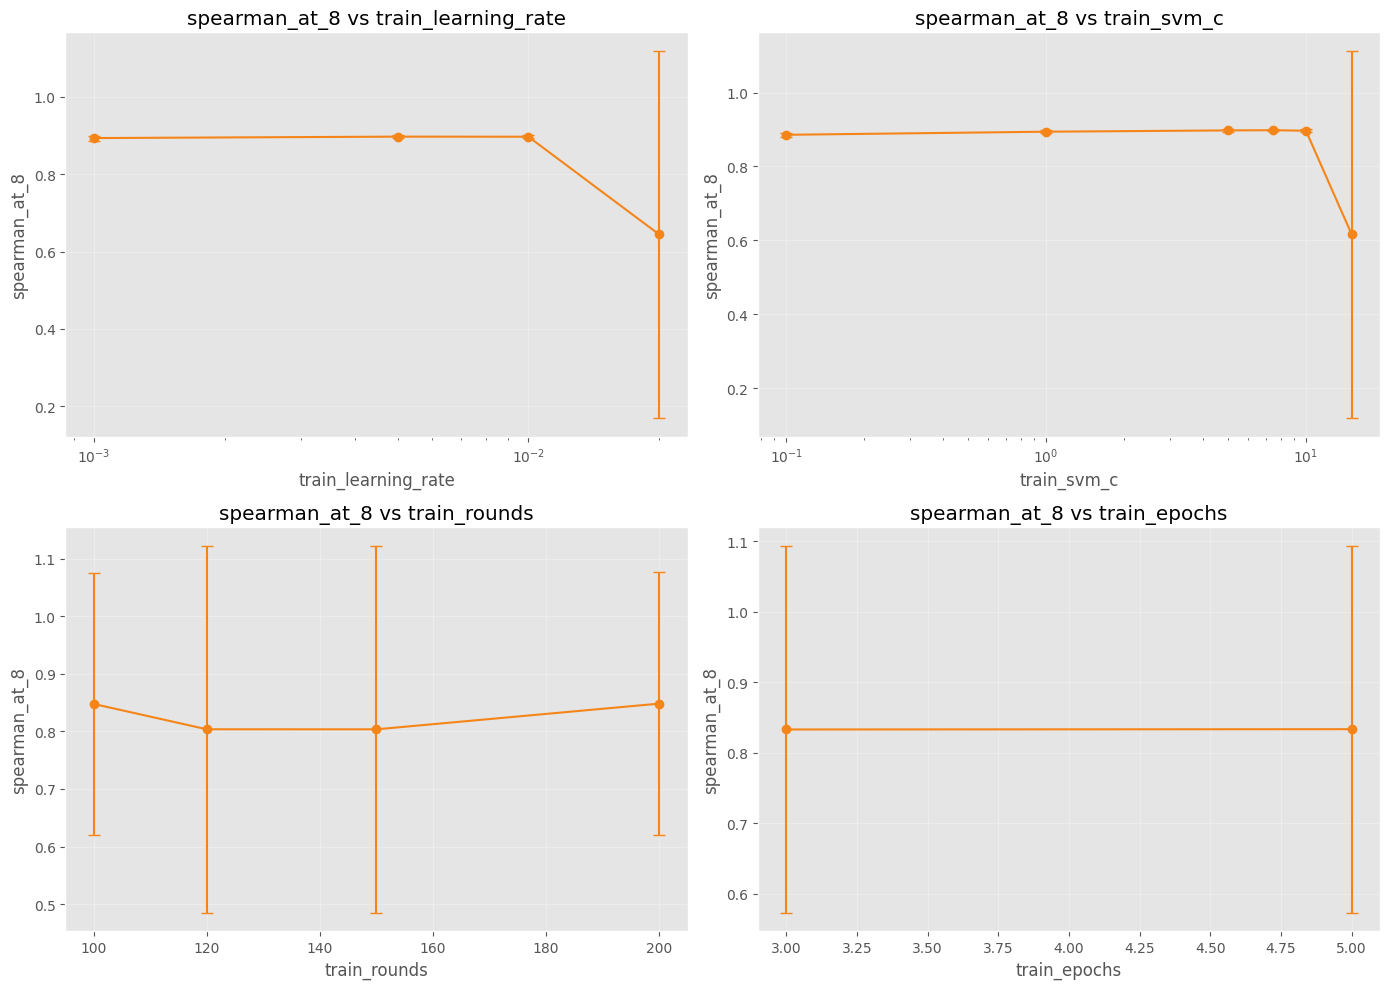

In [6]:
def plot_effect(ax, frame: pd.DataFrame, column: str, metric: str, log_x: bool = False) -> None:
    grouped = (
        frame.groupby(column, dropna=False)[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values(column)
    )
    x = grouped[column].to_numpy()
    y = grouped["mean"].to_numpy()
    yerr = grouped["std"].fillna(0.0).to_numpy()

    ax.errorbar(x, y, yerr=yerr, fmt="-o", capsize=4, color="#F58518")
    ax.set_title(f"{metric} vs {column}")
    ax.set_xlabel(column)
    ax.set_ylabel(metric)
    if log_x:
        ax.set_xscale("log")
    ax.grid(True, alpha=0.3)


if sweep_kind == "clustering":
    candidate_columns = [
        ("clustering_k", False),
        ("clustering_warmup_rounds", False),
        ("clustering_freeze_pca_after_warmup", False),
        ("clustering_enable_pca", False),
        ("clustering_representation", False),
        ("clustering_assignment_margin", False),
        ("clustering_num_restarts", False),
    ]
else:
    candidate_columns = [
        ("train_learning_rate", True),
        ("train_svm_c", True),
        ("train_rounds", False),
        ("train_epochs", False),
    ]

active_columns = [
    (column, log_x)
    for column, log_x in candidate_columns
    if column in df.columns and df[column].dropna().nunique() > 1
]

if not active_columns:
    raise RuntimeError("No varying sweep columns were found to plot.")

ncols = 2
nrows = int(np.ceil(len(active_columns) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes = np.atleast_1d(axes).reshape(-1)

for ax, (column, log_x) in zip(axes, active_columns):
    plot_effect(ax, df, column, PRIMARY_METRIC, log_x=log_x)

for ax in axes[len(active_columns):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


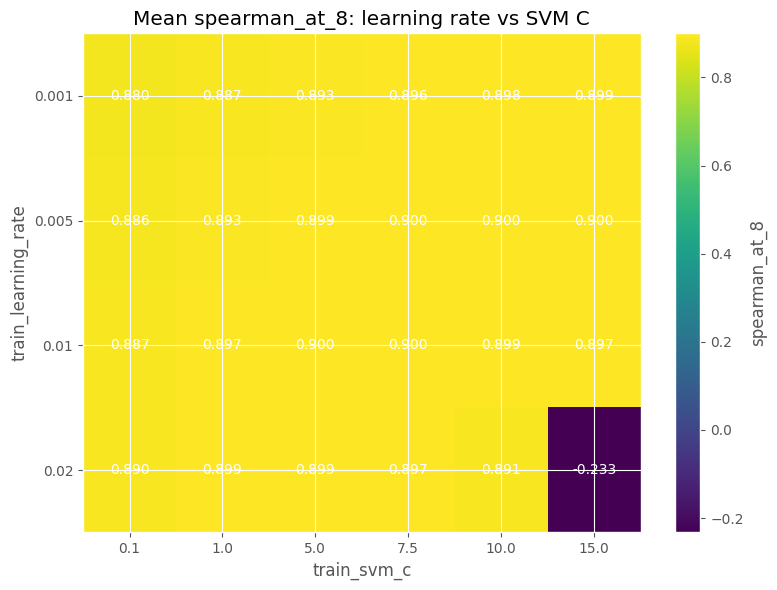

In [7]:
if sweep_kind == "clustering":
    heatmap_index = "clustering_k"
    heatmap_columns = "clustering_warmup_rounds"
    heatmap_title = f"Mean {PRIMARY_METRIC}: clustering_k vs clustering_warmup_rounds"
else:
    heatmap_index = "train_learning_rate"
    heatmap_columns = "train_svm_c"
    heatmap_title = f"Mean {PRIMARY_METRIC}: learning rate vs SVM C"

heatmap_df = (
    df.groupby([heatmap_index, heatmap_columns])[PRIMARY_METRIC]
    .mean()
    .unstack(heatmap_columns)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(heatmap_df.to_numpy(), aspect="auto", cmap="viridis")
ax.set_title(heatmap_title)
ax.set_xlabel(heatmap_columns)
ax.set_ylabel(heatmap_index)
ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels([str(col) for col in heatmap_df.columns])
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels([str(idx) for idx in heatmap_df.index])

for row_idx in range(heatmap_df.shape[0]):
    for col_idx in range(heatmap_df.shape[1]):
        value = heatmap_df.iloc[row_idx, col_idx]
        if pd.notna(value):
            ax.text(col_idx, row_idx, f"{value:.3f}", ha="center", va="center", color="white")

fig.colorbar(im, ax=ax, label=PRIMARY_METRIC)
plt.tight_layout()
plt.show()


In [8]:
if sweep_kind == "clustering":
    grouped_rankings = {
        "clustering_k": df.groupby("clustering_k")[PRIMARY_METRIC].mean().sort_values(ascending=False),
        "clustering_warmup_rounds": df.groupby("clustering_warmup_rounds")[PRIMARY_METRIC].mean().sort_values(ascending=False),
        "clustering_freeze_pca_after_warmup": df.groupby("clustering_freeze_pca_after_warmup")[PRIMARY_METRIC].mean().sort_values(ascending=False),
        "clustering_enable_pca": df.groupby("clustering_enable_pca")[PRIMARY_METRIC].mean().sort_values(ascending=False),
        "clustering_representation": df.groupby("clustering_representation")[PRIMARY_METRIC].mean().sort_values(ascending=False),
        "clustering_assignment_margin": df.groupby("clustering_assignment_margin")[PRIMARY_METRIC].mean().sort_values(ascending=False),
        "clustering_num_restarts": df.groupby("clustering_num_restarts")[PRIMARY_METRIC].mean().sort_values(ascending=False),
    }
else:
    grouped_rankings = {
        "learning_rate": df.groupby("train_learning_rate")[PRIMARY_METRIC].mean().sort_values(ascending=False),
        "svm_c": df.groupby("train_svm_c")[PRIMARY_METRIC].mean().sort_values(ascending=False),
        "rounds": df.groupby("train_rounds")[PRIMARY_METRIC].mean().sort_values(ascending=False),
        "epochs": df.groupby("train_epochs")[PRIMARY_METRIC].mean().sort_values(ascending=False),
    }

for name, series in grouped_rankings.items():
    print(f"\nBest {name} values by mean {PRIMARY_METRIC}")
    display(series.to_frame("mean_metric"))



Best learning_rate values by mean spearman_at_8


,mean_metric
train_learning_rate,
0.005,0.897428
0.010,0.897218
0.001,0.893712
0.020,0.644312



Best svm_c values by mean spearman_at_8


,mean_metric
train_svm_c,
7.5,0.898135
5.0,0.897589
10.0,0.896675
1.0,0.894068
0.1,0.885704
15.0,0.615764



Best rounds values by mean spearman_at_8


,mean_metric
train_rounds,
200,0.848208
100,0.847674
120,0.803653
150,0.803589



Best epochs values by mean spearman_at_8


,mean_metric
train_epochs,
5,0.833381
3,0.832954
